In [1]:
!pip install scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import mean_squared_error

from sklearn.linear_model import SGDClassifier

from lightgbm import LGBMClassifier
from sklearn.ensemble import BaggingClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings("ignore")
import pickle
! pip install openpyxl
! pip install imbalanced-learn
from imblearn.combine import SMOTETomek


In [2]:
df=pd.read_excel(r'E:\data science\dry_bean\dry_bean.xlsx')
df.head(2)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER


In [3]:
df.columns = (
    df.columns
    .str.strip()                             
    .str.lower()                             
    .str.replace(r'\s+', ' ', regex=True)     
    .str.replace(' ', '_')                    
)

In [4]:

print("shape ",df.shape)
print("nan_value  ",df.isnull().sum().sum())
print("duplicate_values"  ,df.duplicated().sum())
print("size ",df.size)


shape  (13611, 17)
nan_value   0
duplicate_values 68
size  231387


In [5]:
df.drop_duplicates(inplace=True)

In [6]:
df.info()

<class 'pandas.DataFrame'>
Index: 13543 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   area             13543 non-null  int64  
 1   perimeter        13543 non-null  float64
 2   majoraxislength  13543 non-null  float64
 3   minoraxislength  13543 non-null  float64
 4   aspectration     13543 non-null  float64
 5   eccentricity     13543 non-null  float64
 6   convexarea       13543 non-null  int64  
 7   equivdiameter    13543 non-null  float64
 8   extent           13543 non-null  float64
 9   solidity         13543 non-null  float64
 10  roundness        13543 non-null  float64
 11  compactness      13543 non-null  float64
 12  shapefactor1     13543 non-null  float64
 13  shapefactor2     13543 non-null  float64
 14  shapefactor3     13543 non-null  float64
 15  shapefactor4     13543 non-null  float64
 16  class            13543 non-null  str    
dtypes: float64(14), int64(2), st

In [7]:
df.describe()

,area,perimeter,majoraxislength,minoraxislength,aspectration,eccentricity,convexarea,equivdiameter,extent,solidity,roundness,compactness,shapefactor1,shapefactor2,shapefactor3,shapefactor4
count,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000
mean,53048.460385,854.993406,319.895602,202.365321,1.581075,0.750315,53767.986709,253.034094,0.749829,0.987152,0.873671,0.800352,0.006561,0.001719,0.644341,0.995078
std,29392.438324,214.722684,85.809260,45.051632,0.245245,0.091858,29844.248525,59.307709,0.048939,0.004650,0.059393,0.061464,0.001130,0.000595,0.098653,0.004347
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36282.500000,703.230000,253.086806,175.886357,1.430662,0.715144,36673.000000,214.933277,0.718735,0.985678,0.833410,0.763228,0.005893,0.001158,0.582517,0.993720
50%,44580.000000,793.896000,296.404589,192.491117,1.549860,0.763997,45122.000000,238.245711,0.759903,0.988288,0.883490,0.801514,0.006643,0.001700,0.642424,0.996393
75%,61382.000000,977.146500,376.312489,217.245403,1.703916,0.809671,62360.000000,279.560351,0.786849,0.990019,0.917031,0.834470,0.007270,0.002173,0.696341,0.997891
max,254616.000000,1985.370000,738.860153,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


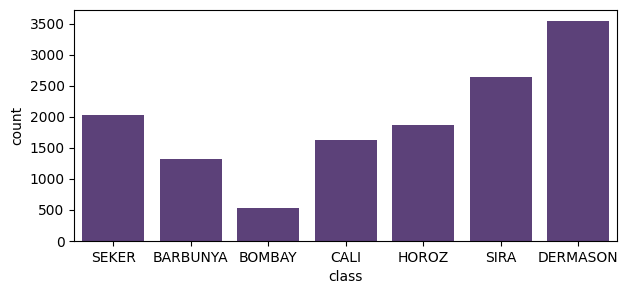

In [8]:
plt.figure(figsize=(7,3))
sns.countplot(x='class', data=df,color='#5C3882')
plt.show()

In [9]:

class_counts = df['class'].value_counts()

print(class_counts)



class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1860
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


In [10]:

le = LabelEncoder()

print("Before:")
print(df['class'].unique())

df['class'] = le.fit_transform(df['class'])

print("After:")
print(df['class'].unique())

Before:
<StringArray>
['SEKER', 'BARBUNYA', 'BOMBAY', 'CALI', 'HOROZ', 'SIRA', 'DERMASON']
Length: 7, dtype: str
After:
[5 0 1 2 4 6 3]


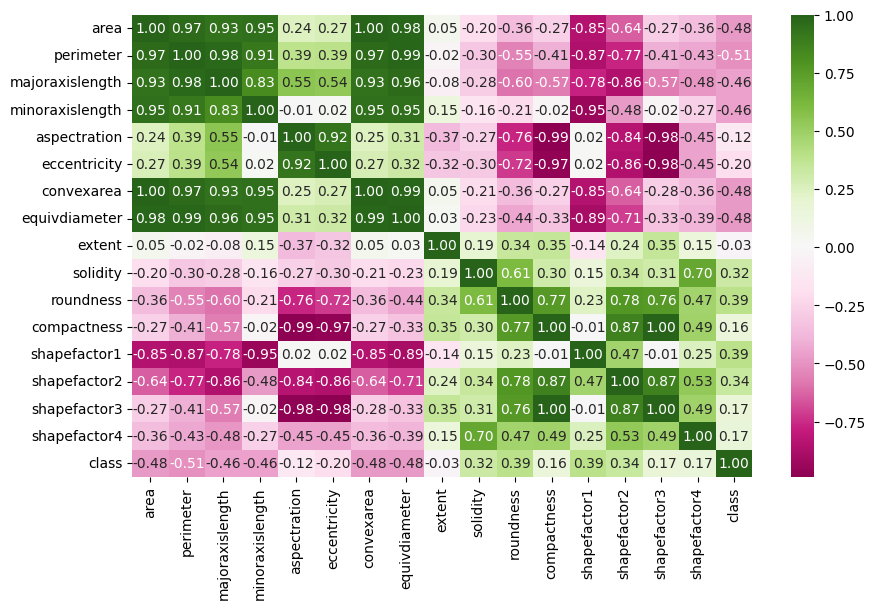

In [11]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='PiYG', fmt='.2f')
plt.show()

In [12]:
corr_with_class = df.corr()['class'].sort_values(ascending=False)

print(corr_with_class)


class              1.000000
shapefactor1       0.391842
roundness          0.388505
shapefactor2       0.337656
solidity           0.323356
shapefactor3       0.170656
shapefactor4       0.167118
compactness        0.159293
extent            -0.030855
aspectration      -0.119588
eccentricity      -0.202824
majoraxislength   -0.456515
minoraxislength   -0.458347
area              -0.475413
convexarea        -0.477624
equivdiameter     -0.481452
perimeter         -0.508315
Name: class, dtype: float64


In [13]:
x = df.drop("class", axis=1)

vif = pd.DataFrame()
vif["Feature"] = x.columns
vif["VIF"] = [
    variance_inflation_factor(x.values, i)
    for i in range(x.shape[1])
]

print(vif.sort_values("VIF", ascending=False))


            Feature           VIF
7     equivdiameter  6.100438e+06
15     shapefactor4  3.107614e+06
11      compactness  2.580923e+06
3   minoraxislength  1.652830e+06
2   majoraxislength  1.317358e+06
9          solidity  6.280427e+05
14     shapefactor3  5.617844e+05
0              area  3.443408e+05
6        convexarea  3.321269e+05
4      aspectration  1.682818e+05
1         perimeter  6.021611e+04
5      eccentricity  2.341323e+04
10        roundness  2.245572e+04
12     shapefactor1  2.091560e+04
13     shapefactor2  1.151162e+04
8            extent  2.933328e+02


In [14]:
df.drop(columns=['equivdiameter','shapefactor4','compactness'],inplace=True)

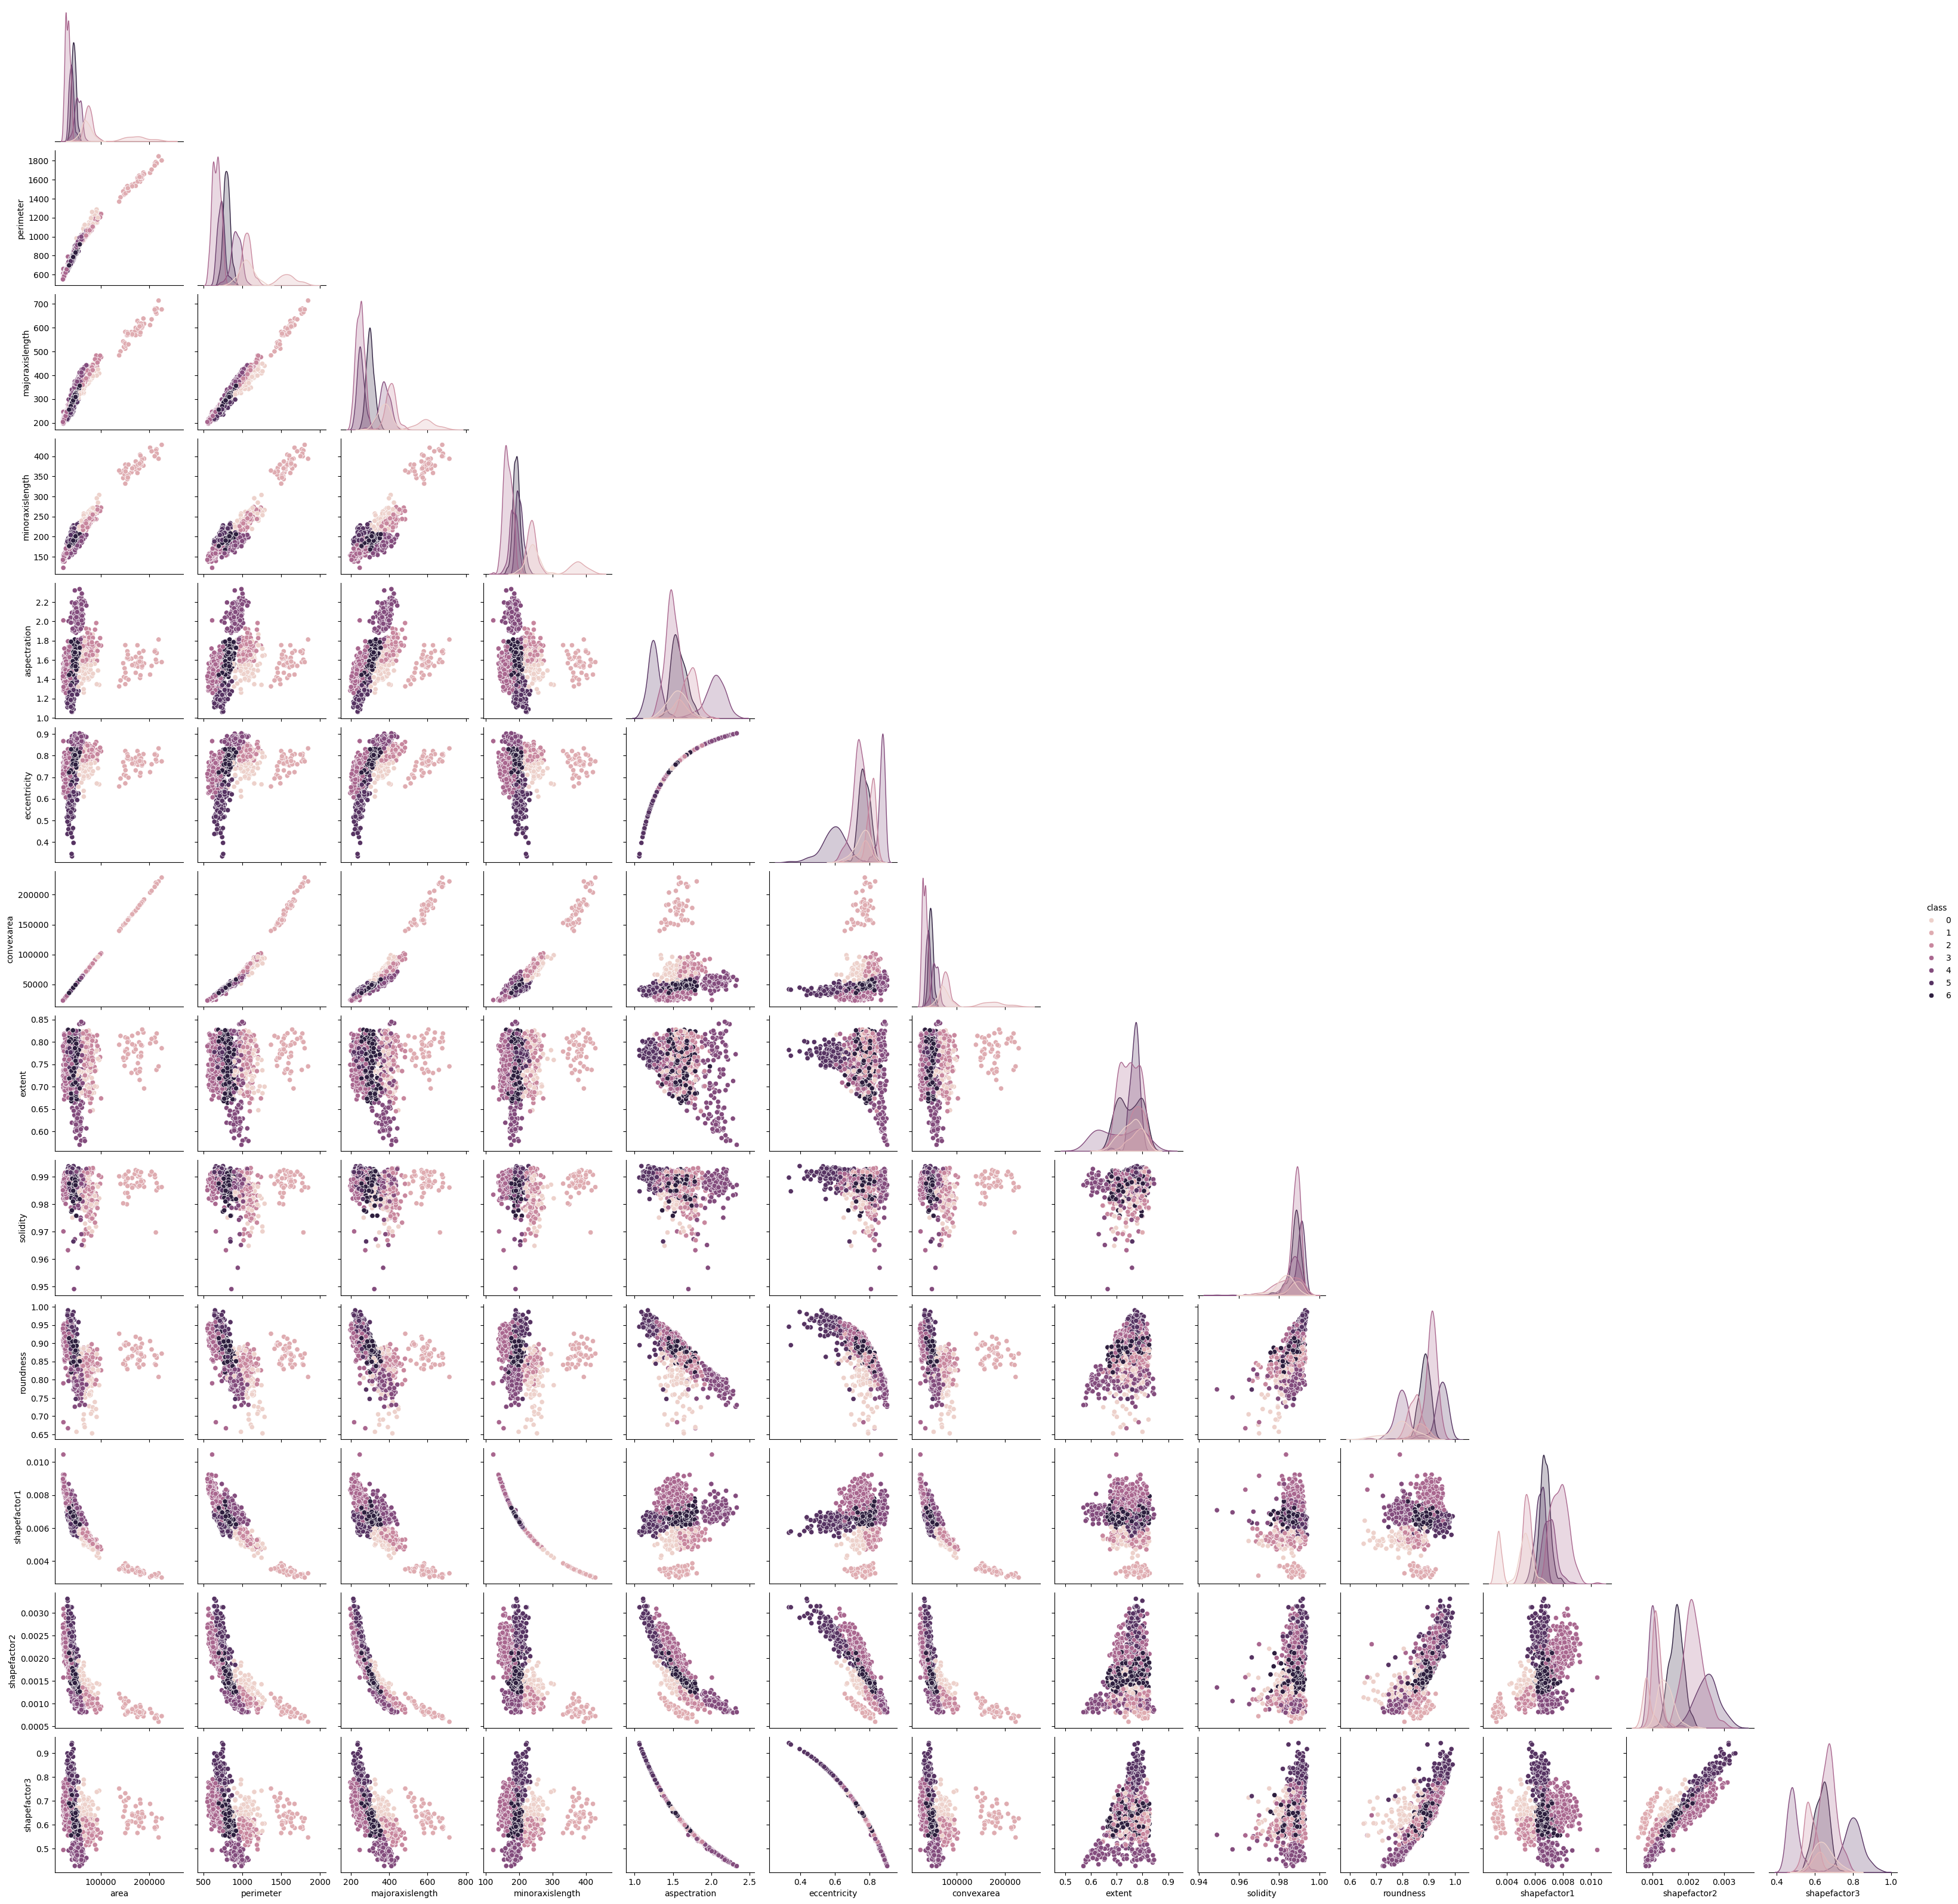

In [15]:
sample_df = df.sample(1000, random_state=42)

sns.pairplot(
    sample_df,
    hue='class',
    corner=True
)
plt.show()


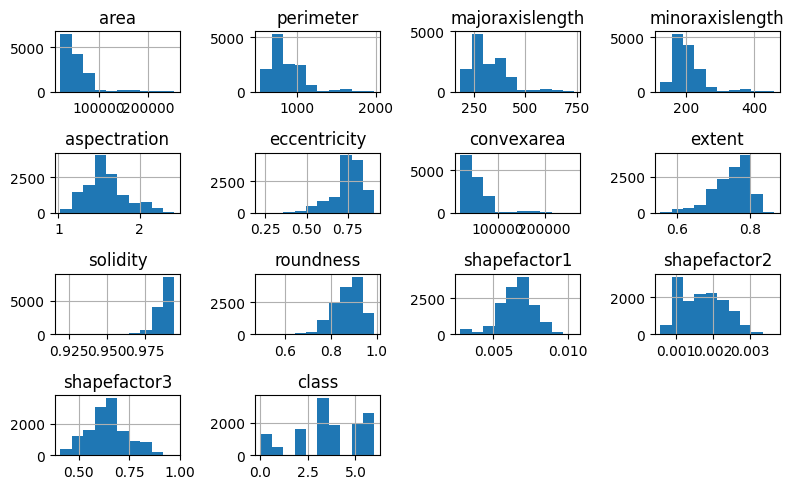

In [16]:
import matplotlib.pyplot as plt

df.hist(figsize=(8,5))
plt.tight_layout()
plt.show()

In [17]:
skewness = df.skew(numeric_only=True).sort_values(ascending=False)
print (skewness)


area               2.947136
convexarea         2.936102
minoraxislength    2.232013
perimeter          1.628018
majoraxislength    1.365813
aspectration       0.589045
shapefactor2       0.294332
shapefactor3       0.242767
class             -0.319689
shapefactor1      -0.530427
roundness         -0.648725
extent            -0.895655
eccentricity      -1.064932
solidity          -2.546877
dtype: float64


In [18]:
skewed_columns=['area',
    'convexarea',
    'minoraxislength',
    'perimeter',
    'majoraxislength']

for i in skewed_columns:
   df[i]=np.log1p(df[i])
df[skewed_columns].skew()


area               1.073117
convexarea         1.067860
minoraxislength    1.307883
perimeter          0.848386
majoraxislength    0.640138
dtype: float64

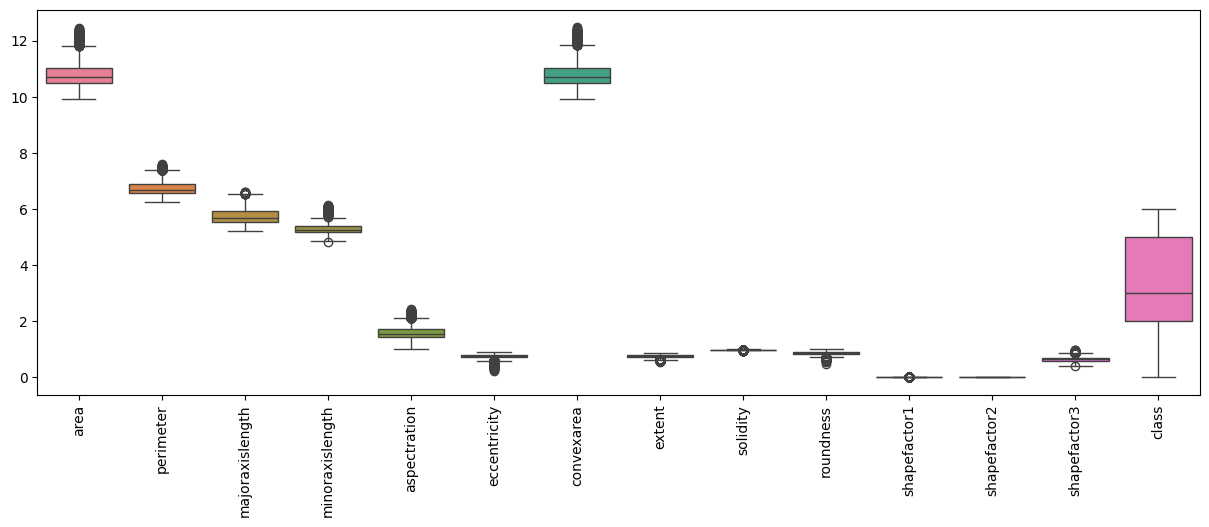

In [19]:
plt.figure(figsize=(15,5))
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.xticks(rotation=90)
plt.show()


In [20]:
for col in df.select_dtypes(include=np.number).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])



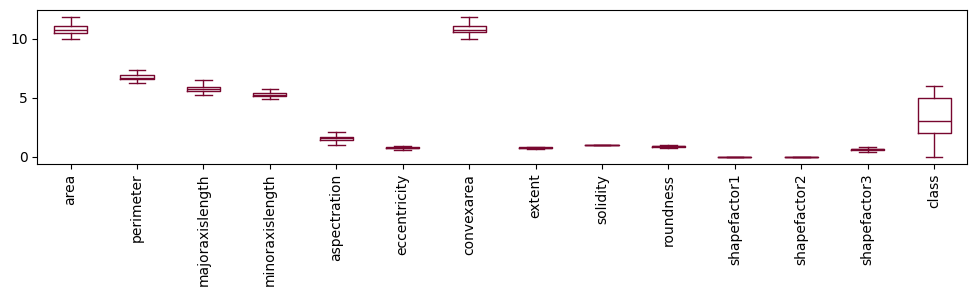

In [21]:
df.plot (kind='box',figsize=(12,2),color='#78072F')
plt.xticks(rotation=90)
plt.show()


In [22]:
x=df.drop('class',axis=1)
y=df['class']
x_train,x_test,y_train,y_test=train_test_split(x,y ,train_size=0.7,random_state=1)
x_train.shape,x_test.shape,y_train.shape,y_test.shape


((9480, 13), (4063, 13), (9480,), (4063,))

In [23]:
scaler=StandardScaler()
x_train_sc=scaler.fit_transform(x_train)
x_test_sc = scaler.transform(x_test)
x_train=pd.DataFrame(x_train_sc,columns=x_train.columns,index=x_train.index)
x_test=pd.DataFrame(x_test_sc,columns=x_test.columns,index=x_test.index)

x_train.head(2)

,area,perimeter,majoraxislength,minoraxislength,aspectration,eccentricity,convexarea,extent,solidity,roundness,shapefactor1,shapefactor2,shapefactor3
558,-0.681010,-0.801557,-1.129559,0.069377,-1.660001,-2.168147,-0.687001,0.430384,0.885291,1.320832,-0.152650,1.860215,2.058917
10506,-1.521434,-1.275742,-1.305073,-1.599326,-0.354609,-0.128702,-1.501846,-1.228699,-1.283064,-0.392463,1.742658,1.026306,0.241660


In [24]:
smt = SMOTETomek(random_state=42)

x_train, y_train = smt.fit_resample(x_train, y_train)

In [25]:
print("After SMOTE")
print(pd.Series(y_train).value_counts())

After SMOTE
class
1.0    2473
0.0    2462
2.0    2460
4.0    2456
5.0    2451
3.0    2385
6.0    2376
Name: count, dtype: int64


In [66]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

def evaluate_classification_model(name, model, x_train, x_test, y_train, y_test):
    model.fit(x_train, y_train)

    train_pred = model.predict(x_train)
    test_pred = model.predict(x_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    
    train_f1 = f1_score(y_train, train_pred, average='weighted')
    test_f1 = f1_score(y_test, test_pred, average='weighted')

    gap = (train_acc - test_acc) * 100

    print("=" * 50)
    print(f"MODEL PERFORMANCE: {name.upper()}")
    print("=" * 50)
    print(f"Training Accuracy : {train_acc*100:.2f}%")
    print(f"Testing Accuracy  : {test_acc*100:.2f}%")
    print(f"Overfitting Gap   : {gap:.2f}%")
    print("-" * 50)
    print(f"Train F1-Score    : {train_f1*100:.2f}%")
    print(f"Test F1-Score     : {test_f1*100:.2f}%")
    print("=" * 50)

    print("\nMODEL VERDICT:")
    if gap > 10:
        print("High Overfitting: Training accuracy is high but testing is low. Model needs regularization.")
    elif gap > 5:
        print("Mild Overfitting: Model gap is in acceptable range but can be improved.")
    else:
        print("Well-Generalized Model: Train and test scores are balanced.")
    
    print("\n" + "-" * 20 + " TESTING CLASSIFICATION REPORT " + "-" * 20)
    print(classification_report(y_test, test_pred))

    return model

In [27]:
print(df['class'].unique())

[5. 0. 1. 2. 4. 6. 3.]


In [67]:
models = {

    "Logistic Regression":
    LogisticRegression(max_iter=2000),

    "Decision Tree":
    DecisionTreeClassifier(class_weight='balanced'),

    "Random Forest":
    RandomForestClassifier(),

    "KNN":
    KNeighborsClassifier(),

    "SVM":
    SVC(),

    "Naive Bayes":
    GaussianNB(),

    "Bagging":
    BaggingClassifier(),

    "XGBoost":
    XGBClassifier(eval_metric='logloss'),

    "CatBoost":
    CatBoostClassifier(verbose=0),

     "Gradient Boosting":
    GradientBoostingClassifier(),
    
    "AdaBoost":
    AdaBoostClassifier(),
    
    "LightGBM":
    LGBMClassifier()
   
}

for name, model in models.items():

    evaluate_classification_model( name,
        model,
        x_train,
        x_test,
        y_train,
        y_test
    )



    

MODEL PERFORMANCE: LOGISTIC REGRESSION
Training Accuracy : 94.00%
Testing Accuracy  : 90.89%
Overfitting Gap   : 3.11%
--------------------------------------------------
Train F1-Score    : 94.02%
Test F1-Score     : 90.90%

MODEL VERDICT:
Well-Generalized Model: Train and test scores are balanced.

-------------------- TESTING CLASSIFICATION REPORT --------------------
              precision    recall  f1-score   support

         0.0       0.92      0.91      0.91       387
         1.0       1.00      1.00      1.00       153
         2.0       0.91      0.94      0.93       490
         3.0       0.93      0.89      0.90      1073
         4.0       0.94      0.94      0.94       533
         5.0       0.92      0.94      0.93       621
         6.0       0.83      0.86      0.84       806

    accuracy                           0.91      4063
   macro avg       0.92      0.92      0.92      4063
weighted avg       0.91      0.91      0.91      4063

MODEL PERFORMANCE: DECISION TR

In [29]:
best_model = df.iloc[0]

print("\nBest Model")
print(best_model)


Best Model
area               10.254004
perimeter           6.415573
majoraxislength     5.343186
minoraxislength     5.164150
aspectration        1.197191
eccentricity        0.573352
convexarea         10.265210
extent              0.763923
solidity            0.988856
roundness           0.958027
shapefactor1        0.007332
shapefactor2        0.003147
shapefactor3        0.834222
class               5.000000
Name: 0, dtype: float64


In [ ]:
model =  SVC()

evaluate_classification_model(
    model,
    x_train,
    x_test,
    y_train,
    y_test
)

In [69]:
base_models =[
       ('dt',DecisionTreeClassifier(max_depth=5,random_state=42)),
        ('rf',RandomForestClassifier(n_estimators=50,random_state=42))
]
meta_model = KNeighborsClassifier()


stacking_classifier = StackingClassifier(
    estimators=base_models,       
    final_estimator=meta_model,
    n_jobs=-1
)


evaluate_classification_model('stacking_classifier',
    model=stacking_classifier,
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test
)

MODEL PERFORMANCE: STACKING_CLASSIFIER
Training Accuracy : 99.68%
Testing Accuracy  : 90.67%
Overfitting Gap   : 9.01%
--------------------------------------------------
Train F1-Score    : 99.68%
Test F1-Score     : 90.66%

MODEL VERDICT:
Mild Overfitting: Model gap is in acceptable range but can be improved.

-------------------- TESTING CLASSIFICATION REPORT --------------------
              precision    recall  f1-score   support

         0.0       0.89      0.88      0.89       387
         1.0       1.00      1.00      1.00       153
         2.0       0.90      0.93      0.92       490
         3.0       0.91      0.90      0.91      1073
         4.0       0.93      0.94      0.94       533
         5.0       0.93      0.93      0.93       621
         6.0       0.85      0.85      0.85       806

    accuracy                           0.91      4063
   macro avg       0.92      0.92      0.92      4063
weighted avg       0.91      0.91      0.91      4063



,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('dt', ...), ('rf', ...)]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",KNeighborsClassifier()
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary <n_jobs>` for more details.",-1
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",None
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,) or list of ndarray if `y` is of type `""multilabel-indicator""`.Class labels.","ndarray[float64](7,)","[0.,1.,2.,...,4.,5.,6.]"
"estimators_ estimators_: list of estimatorsThe elements of the `estimators` parameter, having been fitted on thetraining data. If an estimator has been set to `'drop'`, itwill not appear in `estimators_`. When `cv=""prefit""`, `estimators_`is set to `estimators` and is not fitted again.",list,"[DecisionTreeC...ndom_state=42), RandomForestC...ndom_state=42)]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimators expose such an attribute when fit... versionadded:: 1.0","ndarray[object]

In [55]:
param_grid={
    'max_depth': [6,7,8],
    'min_samples_split' : [5,10,15],
    'min_samples_leaf' :[2,4,6]
}

grid_search=GridSearchCV(estimator=RandomForestClassifier(random_state=42),param_grid=param_grid,cv=5,n_jobs=-1,verbose=2)
grid_search.fit(x_train,y_train)


Fitting 5 folds for each of 27 candidates, totalling 135 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [6, 7, ...], 'min_samples_leaf': [2, 4, ...], 'min_samples_split': [5, 10, ...]}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_

In [65]:
model =  RandomForestClassifier(max_depth=20, min_samples_split=20, min_samples_leaf=1, random_state=42)

evaluate_classification_model('randomforest',
    model,
    x_train,
    x_test,
    y_train,
    y_test
)


MODEL: randomforest
Accuracy: 0.91

Classification Report:
              precision    recall  f1-score   support

         0.0       0.91      0.89      0.90       387
         1.0       1.00      1.00      1.00       153
         2.0       0.91      0.93      0.92       490
         3.0       0.92      0.90      0.91      1073
         4.0       0.95      0.94      0.95       533
         5.0       0.92      0.94      0.93       621
         6.0       0.85      0.86      0.86       806

    accuracy                           0.91      4063
   macro avg       0.92      0.92      0.92      4063
weighted avg       0.91      0.91      0.91      4063


Confusion Matrix:
[[344   0  31   0   1   2   9]
 [  0 153   0   0   0   0   0]
 [ 25   0 455   0   8   1   1]
 [  0   0   0 966   3  22  82]
 [  2   0  12   4 503   0  12]
 [  3   0   0  15   0 586  17]
 [  4   0   3  63  16  23 697]]


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstra

In [31]:
print(np.unique(y_train))

[0. 1. 2. 3. 4. 5. 6.]


In [37]:
models = [
    ("Logistic Regression", LogisticRegression(max_iter=2000)),

    ("Decision Tree", DecisionTreeClassifier()),

    ("Random Forest", RandomForestClassifier()),

    ("KNN", KNeighborsClassifier()),

    ("SVM", SVC()),

    ("Naive Bayes", GaussianNB()),

    ("Bagging", BaggingClassifier()),

    ("Gradient Boosting", GradientBoostingClassifier()),

    ("AdaBoost", AdaBoostClassifier()),

    ("LightGBM", LGBMClassifier(verbose=-1)),

    ("XGBoost", XGBClassifier(eval_metric='logloss', use_label_encoder=False)),

    ("CatBoost", CatBoostClassifier(verbose=0, allow_writing_files=False))
]


def evaluate(y_true, y_pred):
    return (
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, average='weighted', zero_division=0),
        recall_score(y_true, y_pred, average='weighted', zero_division=0),
        f1_score(y_true, y_pred, average='weighted', zero_division=0)
    )

In [ ]:
results = []

for name, model in models:
    try:
        model.fit(x_train, y_train)

        train_pred = model.predict(x_train)
        test_pred = model.predict(x_test)

        acc_tr, prec_tr, rec_tr, f1_tr = evaluate(y_train, train_pred)
        acc_ts, prec_ts, rec_ts, f1_ts = evaluate(y_test, test_pred)

        results.append({
            "Model": name,
            "Train Accuracy": acc_tr,
            "Test Accuracy": acc_ts,
            "Test Precision": prec_ts,
            "Test Recall": rec_ts,
            "Test F1": f1_ts
        })

        print(f"{name} done ✔")

    except Exception as e:
        print(f"{name} skipped  -> {e}")

Logistic Regression done ✔
Decision Tree done ✔
Random Forest done ✔
KNN done ✔
SVM done ✔
Naive Bayes done ✔
Bagging done ✔
Gradient Boosting done ✔
AdaBoost done ✔
LightGBM done ✔
XGBoost done ✔
CatBoost done ✔


In [44]:
df = pd.DataFrame(results)

df = df.sort_values(by="Test Accuracy", ascending=False)


!pip install jinja2


df.style.format("{:.2%}", subset=[
    "Train Accuracy",
    "Test Accuracy",
    "Test Precision",
    "Test Recall",
    "Test F1"
])

,Model,Train Accuracy,Test Accuracy,Test Precision,Test Recall,Test F1
11,CatBoost,98.85%,91.31%,91.33%,91.31%,91.31%
9,LightGBM,99.99%,91.29%,91.32%,91.29%,91.30%
4,SVM,94.68%,91.26%,91.33%,91.26%,91.27%
10,XGBoost,99.99%,91.21%,91.23%,91.21%,91.22%
7,Gradient Boosting,97.06%,91.09%,91.12%,91.09%,91.10%
2,Random Forest,100.00%,91.09%,91.13%,91.09%,91.10%
0,Logistic Regression,94.00%,90.89%,90.95%,90.89%,90.90%
6,Bagging,99.65%,90.13%,90.13%,90.13%,90.13%
3,KNN,97.09%,90.08%,90.17%,90.08%,90.10%
5,Naive Bayes,91.74%,88.73%,88.92%,88.73%,88.75%


In [46]:
best_row = df.loc[df["Test Accuracy"].idxmax()]
print(best_row)
best_model_name = best_row["Model"]
print("Best Model:", best_model_name)

Model             CatBoost
Train Accuracy    0.988513
Test Accuracy     0.913118
Test Precision    0.913295
Test Recall       0.913118
Test F1           0.913115
Name: 11, dtype: object
Best Model: CatBoost


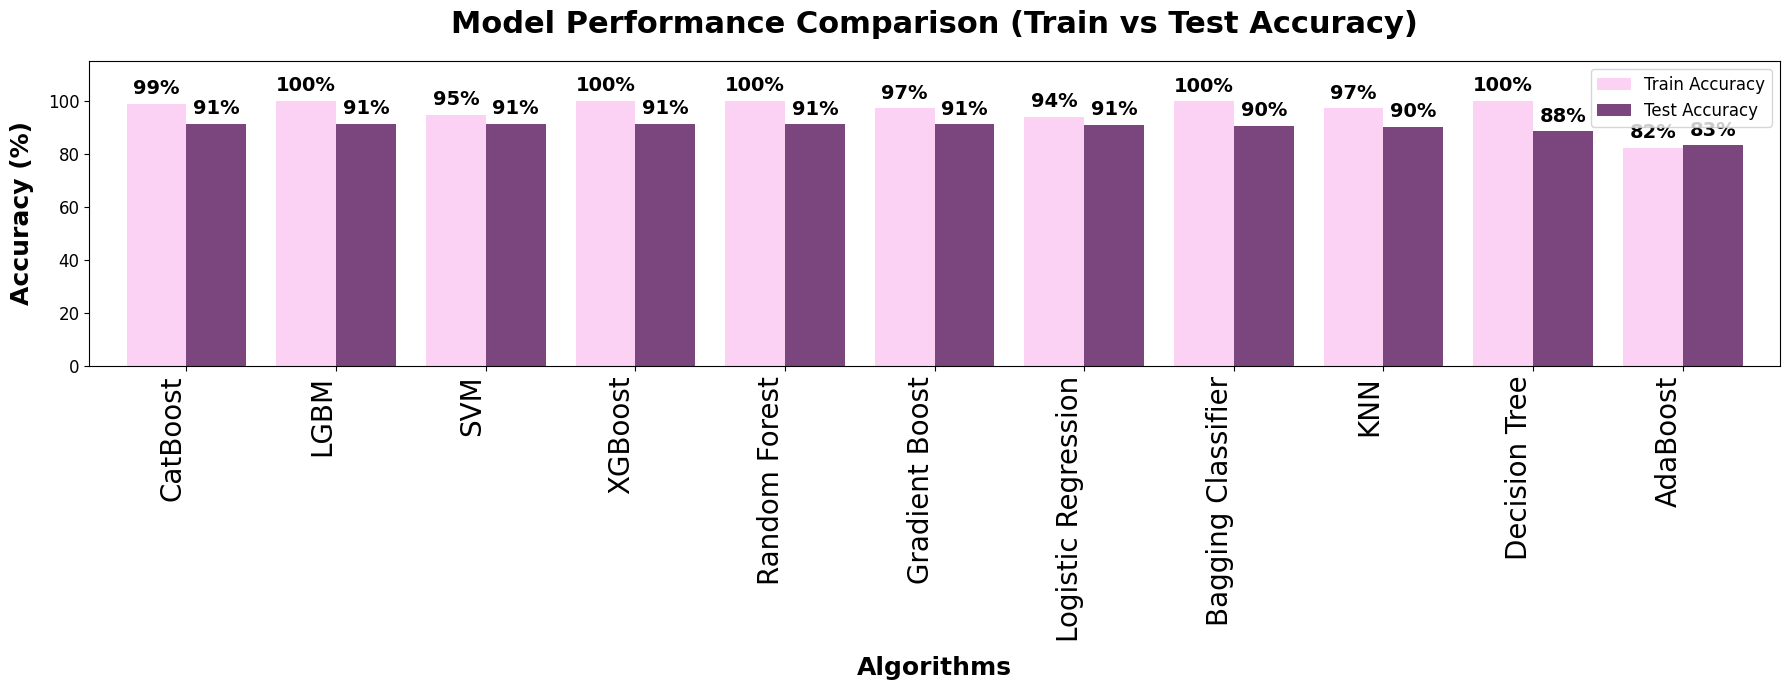

In [49]:
import matplotlib.pyplot as plt


df_plot = df_model.copy()
for col in ['Train Acc', 'Test Acc']:
    if df_plot[col].dtype == 'object':
        df_plot[col] = df_plot[col].astype(str).str.rstrip('%').astype(float)
ax = df_plot.plot(
    x="Algorithms",
    y=["Train Acc", "Test Acc"],  
    kind="bar",  
    figsize=(18, 7), 
    color=["#FCD2F4", "#7A467D"],  
    width=0.8
)


plt.title("Model Performance Comparison (Train vs Test Accuracy)", fontsize=22, fontweight="bold", pad=20) 
plt.xlabel("Algorithms", fontsize=18, fontweight="bold", labelpad=10)  
plt.ylabel("Accuracy (%)", fontsize=18, fontweight="bold", labelpad=10)  

plt.xticks(rotation=90, ha='right', fontsize=20
          ) 
plt.yticks(fontsize=12)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f%%', label_type='edge', fontsize=14, padding=4, fontweight='bold')
plt.legend(["Train Accuracy", "Test Accuracy"], fontsize=12, loc='upper right')
plt.ylim(0, 115) 
plt.tight_layout()
plt.show()

In [81]:
best_model = SVC(random_state=42)

In [83]:
from sklearn.svm import SVC
import joblib

best_model = SVC(random_state=42)

best_model.fit(x_train, y_train)

joblib.dump(best_model, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model and Scaler saved successfully!")

Model and Scaler saved successfully!
